In [1]:
import math
import time
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import pandas as pd

import os
import random
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Датасеты / трансформации
import torchvision
from torchvision import transforms
from torchvision.datasets import EMNIST

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)

torch: 2.8.0+cpu
torchvision: 0.23.0+cpu
device: cpu
torch: 2.8.0+cpu


In [2]:
def set_seed(seed: int = 42) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [3]:
DEFAULT_NUM_WORKERS = 0
BATCH_SIZE = 128
VAL_RATIO = 0.2
RANDOM_SEED = 42

def load_emnist_balanced():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    train_full = EMNIST(
        root='./data',
        split='balanced',
        train=True,
        download=True,
        transform=transform
    )

    test_ds = EMNIST(
        root='./data',
        split='balanced',
        train=False,
        download=True,
        transform=transform
    )

    print("EMNIST(split='balanced') загружен:")
    print(f"Train full: {len(train_full)} изображений")
    print(f"Test: {len(test_ds)} изображений")
    print(f"Количество классов: {len(train_full.classes)}")

    return train_full, test_ds

def make_loaders(ds_train_full, ds_test, batch_size: int = BATCH_SIZE, val_ratio: float = VAL_RATIO, seed: int = RANDOM_SEED):
    n_total = len(ds_train_full)
    n_val = int(n_total * val_ratio)
    n_train = n_total - n_val

    print(f"Разбиение dataset:")
    print(f"Всего train: {n_total}")
    print(f"Train: {n_train} ({n_train/n_total*100}%)")
    print(f"Val: {n_val} ({n_val/n_total*100}%)")

    #воспроизводимость
    gen = torch.Generator().manual_seed(seed)
    ds_train, ds_val = random_split(
        ds_train_full,
        [n_train, n_val],
        generator=gen
    )

    #DataLoader
    train_loader = DataLoader(
        ds_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=DEFAULT_NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        ds_val,
        batch_size=batch_size,
        shuffle=False,
        num_workers=DEFAULT_NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        ds_test,
        batch_size=batch_size,
        shuffle=False,
        num_workers=DEFAULT_NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, val_loader, test_loader

In [4]:
train_full, test_ds = load_emnist_balanced()

#DataLoader
train_loader, val_loader, test_loader = make_loaders(
    ds_train_full=train_full,
    ds_test=test_ds,
    batch_size=128,
    val_ratio=0.2,
    seed=42
)

#Sanity check
x, y = next(iter(train_loader))
print(f"\nSanity check:")
print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")
print(f"x min: {x.min().item()}")
print(f"x max: {x.max().item()}")

#Константы для модели
INPUT_DIM = 28 * 28  # 784 - для Flatten слоя
NUM_CLASSES = 47     # количество классов EMNIST balanced

100.0%


EMNIST(split='balanced') загружен:
Train full: 112800 изображений
Test: 18800 изображений
Количество классов: 47
Разбиение dataset:
Всего train: 112800
Train: 90240 (80.0%)
Val: 22560 (20.0%)

Sanity check:
x shape: torch.Size([128, 1, 28, 28])
y shape: torch.Size([128])
x min: -1.0
x max: 1.0


In [5]:
class MLP(nn.Module):
    def __init__(
        self,
        input_shape: Tuple[int, int, int],
        num_classes: int,
        hidden_sizes: List[int] = [256, 128],
        activation: str = "relu",
        use_batchnorm: bool = False,
        dropout: float = 0.0,
    ):
        super().__init__()
        c, h, w = input_shape
        in_features = c * h * w

        act_layer = {
            "relu": nn.ReLU,
            "tanh": nn.Tanh,
            "gelu": nn.GELU,
        }.get(activation.lower(), nn.ReLU)

        layers: List[nn.Module] = [nn.Flatten()]

        prev = in_features
        for hs in hidden_sizes:
            layers.append(nn.Linear(prev, hs))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hs))
            layers.append(act_layer())
            if dropout and dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = hs

        layers.append(nn.Linear(prev, num_classes))  # logits
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [6]:
def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

def grad_global_norm(parameters) -> float:
    total_norm_sq = 0.0
    for p in parameters:
        if p.grad is None:
            continue
        param_norm = p.grad.data.norm(2).item()
        total_norm_sq += param_norm ** 2
    return math.sqrt(total_norm_sq)

In [7]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    max_grad_norm: Optional[float] = None,
    log_grad_norm: bool = False,
):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n = 0

    grad_norms_before = []
    grad_norms_after = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        # иногда на очень агрессивных настройках бывает NaN – делаем мягкую защиту
        if not torch.isfinite(loss):
            continue

        loss.backward()

        if log_grad_norm:
            gn_before = grad_global_norm(model.parameters())
            grad_norms_before.append(gn_before)

        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            if log_grad_norm:
                gn_after = grad_global_norm(model.parameters())
                grad_norms_after.append(gn_after)

        optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_from_logits(logits, y) * bs
        n += bs

    avg_loss = float(total_loss / max(1, n))
    avg_acc = float(total_acc / max(1, n))

    return avg_loss, avg_acc


In [8]:
@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        if not torch.isfinite(loss):
            continue
        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_from_logits(logits, y) * bs
        n += bs
    return float(total_loss / max(1, n)), float(total_acc / max(1, n))

def plot_history(history: Dict[str, List[float]], title: str = ""):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(list(epochs), history["train_loss"], label="train_loss")
    plt.plot(list(epochs), history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title or "Loss curves")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(list(epochs), history["train_acc"], label="train_acc")
    plt.plot(list(epochs), history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title or "Accuracy curves")
    plt.legend()
    plt.show()

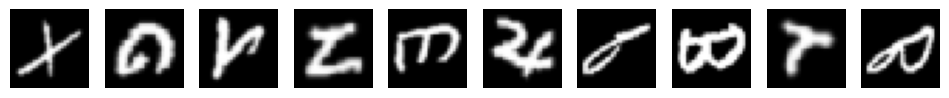

In [9]:
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        # Обратно денормализуем для отображения
        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

In [10]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [11]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

In [12]:
def get_best_metrics(history):
    """Извлекает лучшие метрики из истории"""
    best_epoch = np.argmax(history['val_acc'])
    return {
        'best_val_acc': history['val_acc'][best_epoch],
        'best_val_loss': history['val_loss'][best_epoch],
        'epochs_trained': len(history['val_acc'])
    }

epoch 01/20 | train loss=1.3376, acc=0.6199 | val loss=0.8952, acc=0.7294
epoch 02/20 | train loss=0.7551, acc=0.7662 | val loss=0.7094, acc=0.7771
epoch 03/20 | train loss=0.6180, acc=0.8006 | val loss=0.6130, acc=0.8047
epoch 04/20 | train loss=0.5445, acc=0.8192 | val loss=0.5765, acc=0.8160
epoch 05/20 | train loss=0.5046, acc=0.8308 | val loss=0.5517, acc=0.8170
epoch 06/20 | train loss=0.4728, acc=0.8393 | val loss=0.5451, acc=0.8242
epoch 07/20 | train loss=0.4461, acc=0.8465 | val loss=0.5276, acc=0.8281
epoch 08/20 | train loss=0.4277, acc=0.8512 | val loss=0.5454, acc=0.8223
epoch 09/20 | train loss=0.4103, acc=0.8554 | val loss=0.5126, acc=0.8355
epoch 10/20 | train loss=0.3940, acc=0.8591 | val loss=0.5221, acc=0.8313
epoch 11/20 | train loss=0.3804, acc=0.8637 | val loss=0.5200, acc=0.8332
epoch 12/20 | train loss=0.3672, acc=0.8665 | val loss=0.5243, acc=0.8330
epoch 13/20 | train loss=0.3554, acc=0.8696 | val loss=0.5200, acc=0.8347
epoch 14/20 | train loss=0.3436, acc=0

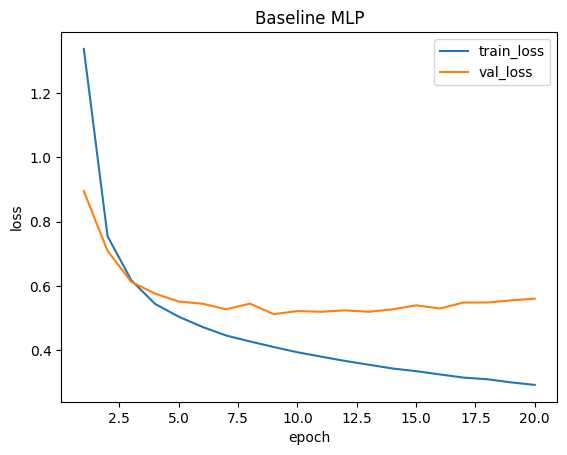

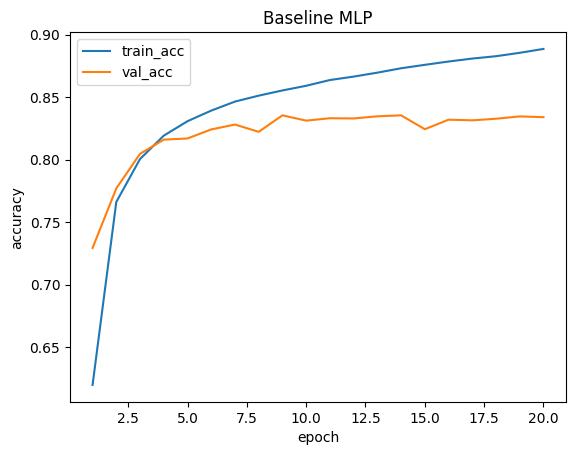

In [13]:
all_results = []

baseline = MLP(input_shape=(1, 28, 28), num_classes=NUM_CLASSES, hidden_sizes=(256, 128), dropout=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_e1 = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_e1, title="Baseline MLP")

In [32]:
metrics_e1 = get_best_metrics(history_e1)
all_results = []
all_results.append({
    'experiment_id': 'E1',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': 'MLP(256,128)',
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': None,
    'weight_decay': 0.0,
    'epochs_trained': metrics_e1['epochs_trained'],
    'best_val_accuracy': metrics_e1['best_val_acc'],
    'best_val_loss': metrics_e1['best_val_loss']
})

print(f"E1 best val_acc: {metrics_e1['best_val_acc']:.4f}")

df = pd.DataFrame(all_results)
df.to_csv('artifacts/runs.csv', index=False)
print("\nРезультаты сохранены в artifacts/runs.csv")

E1 best val_acc: 0.8355

Результаты сохранены в artifacts/runs.csv


epoch 01/20 | train loss=1.6771, acc=0.5190 | val loss=0.9472, acc=0.7160
epoch 02/20 | train loss=1.0813, acc=0.6689 | val loss=0.7630, acc=0.7650
epoch 03/20 | train loss=0.9561, acc=0.7033 | val loss=0.6844, acc=0.7851
epoch 04/20 | train loss=0.8960, acc=0.7201 | val loss=0.6591, acc=0.7920
epoch 05/20 | train loss=0.8510, acc=0.7310 | val loss=0.6201, acc=0.8031
epoch 06/20 | train loss=0.8152, acc=0.7399 | val loss=0.5975, acc=0.8082
epoch 07/20 | train loss=0.8007, acc=0.7439 | val loss=0.5891, acc=0.8071
epoch 08/20 | train loss=0.7793, acc=0.7474 | val loss=0.5690, acc=0.8121
epoch 09/20 | train loss=0.7627, acc=0.7536 | val loss=0.5632, acc=0.8184
epoch 10/20 | train loss=0.7529, acc=0.7580 | val loss=0.5559, acc=0.8184
epoch 11/20 | train loss=0.7380, acc=0.7599 | val loss=0.5400, acc=0.8231
epoch 12/20 | train loss=0.7271, acc=0.7625 | val loss=0.5391, acc=0.8240
epoch 13/20 | train loss=0.7217, acc=0.7641 | val loss=0.5367, acc=0.8218
epoch 14/20 | train loss=0.7132, acc=0

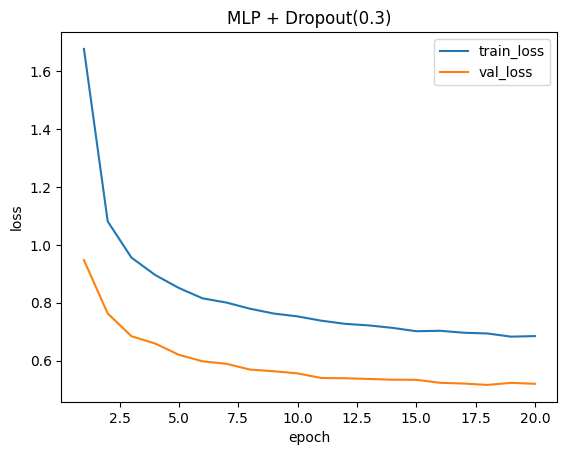

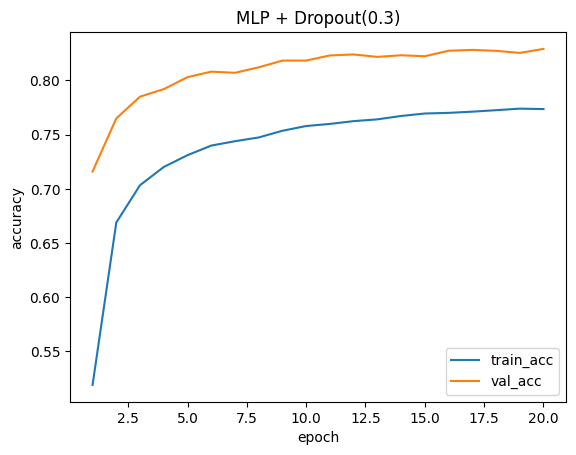

In [18]:
set_seed(42)
dropout_model = MLP(input_shape=(1, 28, 28), num_classes=NUM_CLASSES, hidden_sizes=(256, 128), dropout=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

history_dropout = fit(
    dropout_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_dropout, title="MLP + Dropout(0.3)")

In [33]:
all_results_e2 = []
metrics_e2 = get_best_metrics(history_dropout)
all_results_e2.append({
    'experiment_id': 'E2',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': 'MLP(256,128), dropout=0.3',
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': None,
    'weight_decay': 0.0,
    'epochs_trained': metrics_e2['epochs_trained'],
    'best_val_accuracy': metrics_e2['best_val_acc'],
    'best_val_loss': metrics_e2['best_val_loss']
})

print(f"E2 best val_acc: {metrics_e2['best_val_acc']:.4f}")

df = pd.DataFrame(all_results_e2)
df.to_csv('artifacts/runs.csv', mode='a', index=False, header=False)
print("\nРезультаты сохранены в artifacts/runs.csv")

E2 best val_acc: 0.8291

Результаты сохранены в artifacts/runs.csv


epoch 01/20 | train loss=0.9952, acc=0.7283 | val loss=0.5965, acc=0.8113
epoch 02/20 | train loss=0.5274, acc=0.8259 | val loss=0.5118, acc=0.8312
epoch 03/20 | train loss=0.4489, acc=0.8465 | val loss=0.4931, acc=0.8371
epoch 04/20 | train loss=0.4025, acc=0.8592 | val loss=0.4739, acc=0.8420
epoch 05/20 | train loss=0.3707, acc=0.8683 | val loss=0.4701, acc=0.8394
epoch 06/20 | train loss=0.3431, acc=0.8754 | val loss=0.4635, acc=0.8449
epoch 07/20 | train loss=0.3228, acc=0.8818 | val loss=0.4651, acc=0.8467
epoch 08/20 | train loss=0.3055, acc=0.8867 | val loss=0.4648, acc=0.8465
epoch 09/20 | train loss=0.2868, acc=0.8924 | val loss=0.4648, acc=0.8495
epoch 10/20 | train loss=0.2737, acc=0.8953 | val loss=0.4734, acc=0.8490
epoch 11/20 | train loss=0.2623, acc=0.8998 | val loss=0.4818, acc=0.8474
epoch 12/20 | train loss=0.2489, acc=0.9036 | val loss=0.4881, acc=0.8441
epoch 13/20 | train loss=0.2386, acc=0.9078 | val loss=0.5007, acc=0.8464
epoch 14/20 | train loss=0.2294, acc=0

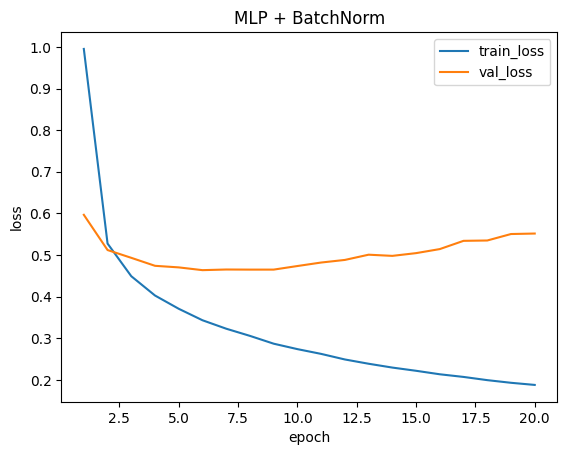

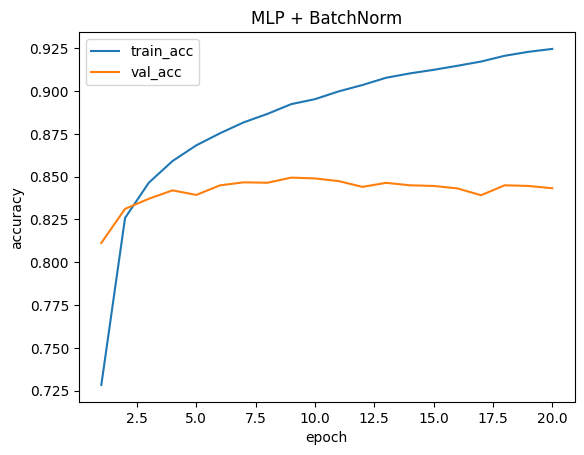

In [23]:
set_seed(42)
bn_model = MLP(input_shape=(1, 28, 28), num_classes=NUM_CLASSES, hidden_sizes=(256, 128), dropout=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model.parameters(), lr=1e-3)

history_bn = fit(
    bn_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_bn, title="MLP + BatchNorm")

In [34]:
all_results_e3 = []
metrics_e3 = get_best_metrics(history_bn)
all_results_e3.append({
    'experiment_id': 'E3',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': 'MLP(256,128), BatchNorm',
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': None,
    'weight_decay': 0.0,
    'epochs_trained': metrics_e3['epochs_trained'],
    'best_val_accuracy': metrics_e3['best_val_acc'],
    'best_val_loss': metrics_e3['best_val_loss']
})

print(f"E3 best val_acc: {metrics_e3['best_val_acc']:.4f}")

df = pd.DataFrame(all_results_e3)
df.to_csv('artifacts/runs.csv', mode='a', index=False, header=False)
print("\nРезультаты сохранены в artifacts/runs.csv")

E3 best val_acc: 0.8495

Результаты сохранены в artifacts/runs.csv


Лучший: E3 (с BatchNorm), так как у него самая высокая точность на валидации (84.95% против 82.91%).

epoch 01/50 | train loss=0.9950, acc=0.7304 | val loss=0.6104, acc=0.8043
epoch 02/50 | train loss=0.5273, acc=0.8261 | val loss=0.5164, acc=0.8291
epoch 03/50 | train loss=0.4478, acc=0.8453 | val loss=0.4878, acc=0.8348
epoch 04/50 | train loss=0.3999, acc=0.8604 | val loss=0.4781, acc=0.8404
epoch 05/50 | train loss=0.3687, acc=0.8689 | val loss=0.4857, acc=0.8369
epoch 06/50 | train loss=0.3435, acc=0.8750 | val loss=0.4633, acc=0.8453
epoch 07/50 | train loss=0.3205, acc=0.8829 | val loss=0.4717, acc=0.8397
epoch 08/50 | train loss=0.3032, acc=0.8869 | val loss=0.4692, acc=0.8464
epoch 09/50 | train loss=0.2868, acc=0.8911 | val loss=0.4725, acc=0.8470
epoch 10/50 | train loss=0.2717, acc=0.8965 | val loss=0.4732, acc=0.8479
epoch 11/50 | train loss=0.2608, acc=0.8989 | val loss=0.4911, acc=0.8426
epoch 12/50 | train loss=0.2472, acc=0.9045 | val loss=0.4862, acc=0.8473
epoch 13/50 | train loss=0.2372, acc=0.9078 | val loss=0.4991, acc=0.8445
epoch 14/50 | train loss=0.2299, acc=0

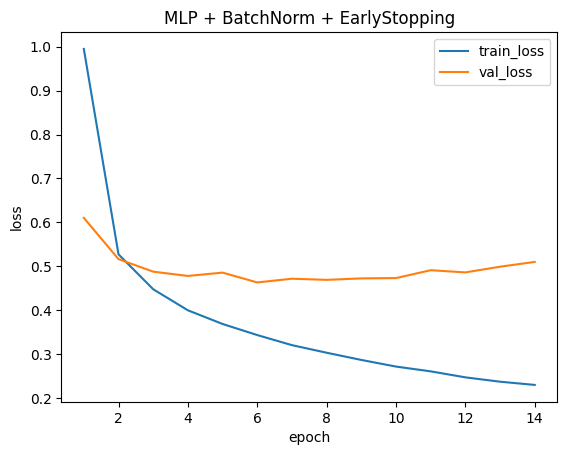

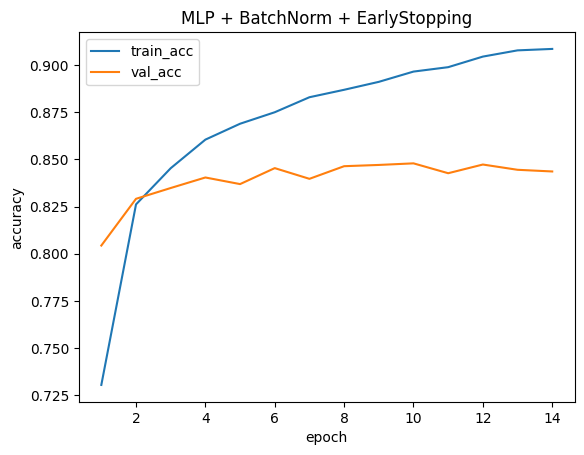

In [26]:
model_e4 = MLP(input_shape=(1, 28, 28), num_classes=NUM_CLASSES, hidden_sizes=(256, 128), dropout=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_e4.parameters(), lr=1e-3)

es = EarlyStopping(patience=4, min_delta=0.0005)

history_e4 = fit(
    model_e4, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=50,  # дадим больше эпох, но остановимся рано
    early_stopping=es,
    verbose=True
)

plot_history(history_e4, title="MLP + BatchNorm + EarlyStopping")

In [27]:
test_loss, test_acc = evaluate(model_e4, test_loader, criterion, device)

In [35]:
print(f"Model E4 test: loss={test_loss:.4f}, acc={test_acc:.4f}")

all_results_e4 = []
metrics_e4 = get_best_metrics(history_e4)
all_results_e4.append({
    'experiment_id': 'E4',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': 'MLP(256,128), BatchNorm, EarlyStopping (patience=4, min_delta=0.0005)',
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': None,
    'weight_decay': 0.0,
    'epochs_trained': metrics_e4['epochs_trained'],
    'best_val_accuracy': metrics_e4['best_val_acc'],
    'best_val_loss': metrics_e4['best_val_loss']
})

print(f"E4 best val_acc: {metrics_e4['best_val_acc']:.4f}")

df = pd.DataFrame(all_results_e4)
df.to_csv('artifacts/runs.csv', mode='a', index=False, header=False)
print("\nРезультаты сохранены в artifacts/runs.csv")

Model E4 test: loss=0.4951, acc=0.8432
E4 best val_acc: 0.8479

Результаты сохранены в artifacts/runs.csv


In [36]:
best_model_path = 'artifacts/best_model.pt'
torch.save(model_e4.state_dict(), best_model_path)
print(f"Модель сохранена: {best_model_path}")

Модель сохранена: artifacts/best_model.pt


In [38]:
import json
best_config = {
    'experiment_id': 'E4',
    'dataset': 'EMNIST',
    'seed': 42,
    'model': {
        'architecture': 'MLP',
        'input_shape': [1, 28, 28],
        'hidden_sizes': [256, 128],
        'dropout': 0.0,
        'use_batchnorm': True,
        'num_classes': NUM_CLASSES  # Убедитесь, что эта переменная определена
    },
    'training': {
        'optimizer': 'Adam',
        'learning_rate': 0.001,
        'weight_decay': 0.0,
        'momentum': None,
        'criterion': 'CrossEntropyLoss',
        'batch_size': train_loader.batch_size,  # Предполагается, что train_loader определен
        'epochs_max': 50,
        'epochs_trained': metrics_e4['epochs_trained'],
        'early_stopping': {
            'patience': 4,
            'min_delta': 0.0005
        }
    },
    'results': {
        'best_val_accuracy': float(metrics_e4['best_val_acc']),
        'best_val_loss': float(metrics_e4['best_val_loss']),
        'test_accuracy': float(test_acc),
        'test_loss': float(test_loss)
    }
}

# Сохраняем конфиг в JSON
config_path = 'artifacts/best_config.json'
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(best_config, f, indent=2, ensure_ascii=False)
print(f"Конфиг сохранен: {config_path}")

Конфиг сохранен: artifacts/best_config.json


График сохранен: artifacts/figures/curves_best.png


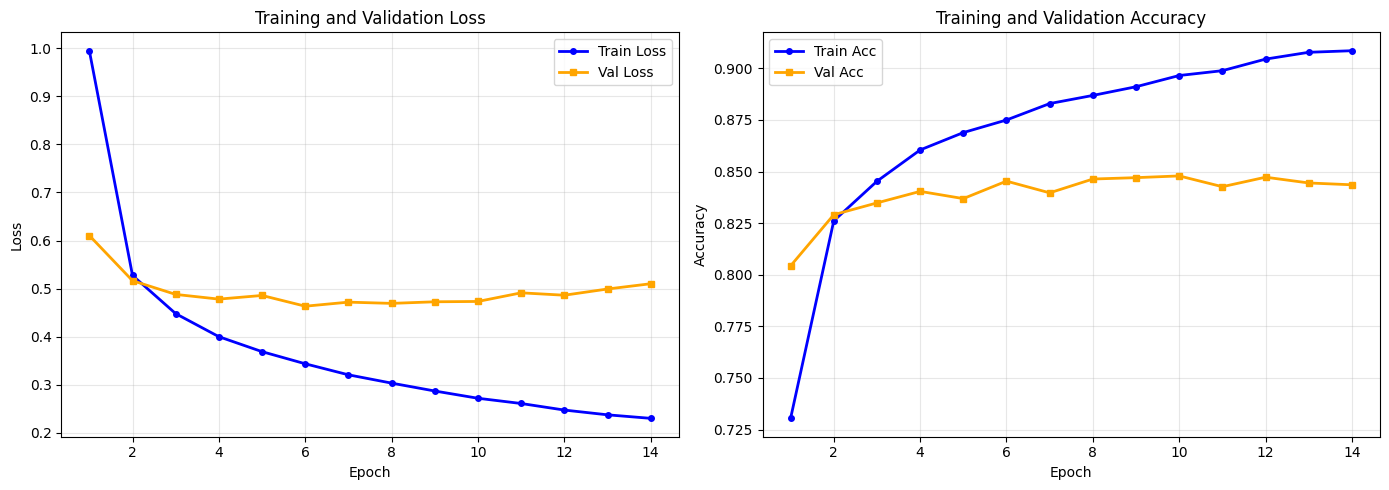

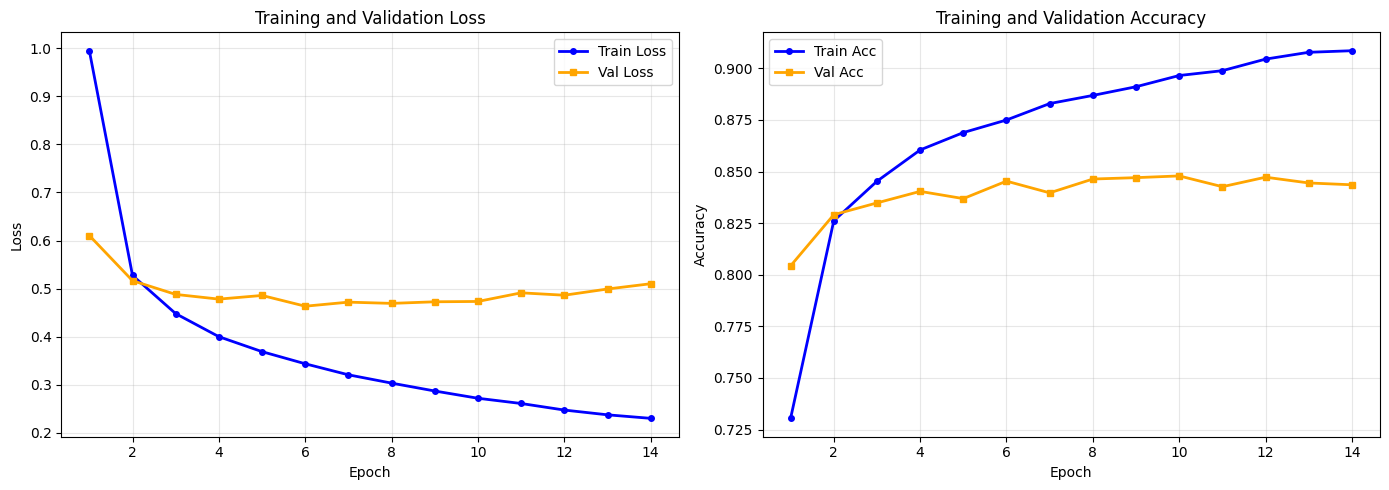

In [46]:
def save_training_curves(history, save_path='figures/curves_best.png', title=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(1, len(history['train_loss']) + 1)
    
    # График loss
    axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='blue', linewidth=2, marker='o', markersize=4)
    axes[0].plot(epochs, history['val_loss'], label='Val Loss', color='orange', linewidth=2, marker='s', markersize=4)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    
    # График accuracy
    axes[1].plot(epochs, history['train_acc'], label='Train Acc', color='blue', linewidth=2, marker='o', markersize=4)
    axes[1].plot(epochs, history['val_acc'], label='Val Acc', color='orange', linewidth=2, marker='s', markersize=4)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    print(f"График сохранен: {save_path}")
    
    return fig

save_training_curves(
    history_e4, 
    save_path='artifacts/figures/curves_best.png',
    title="MLP + BatchNorm + EarlyStopping (Patience=4)"
)

O1 (LR слишком большой): lr=0.1

epoch 01/6 | train loss=1.0858, acc=0.6734 | val loss=0.8673, acc=0.7295
epoch 02/6 | train loss=0.7774, acc=0.7509 | val loss=0.7510, acc=0.7579
epoch 03/6 | train loss=0.7132, acc=0.7696 | val loss=0.6973, acc=0.7739
epoch 04/6 | train loss=0.6547, acc=0.7844 | val loss=0.6928, acc=0.7797
epoch 05/6 | train loss=0.6333, acc=0.7927 | val loss=0.6396, acc=0.7979
epoch 06/6 | train loss=0.6168, acc=0.7967 | val loss=0.6965, acc=0.7792


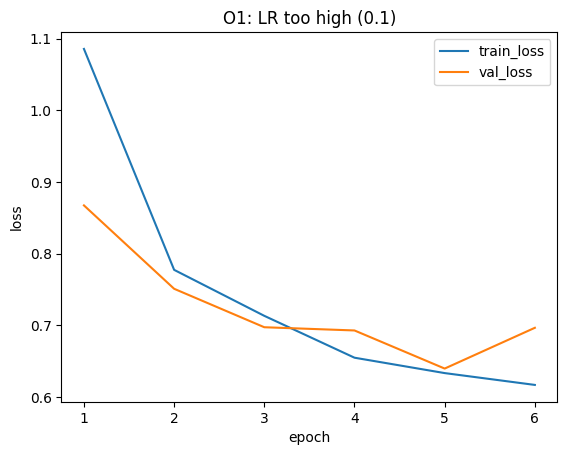

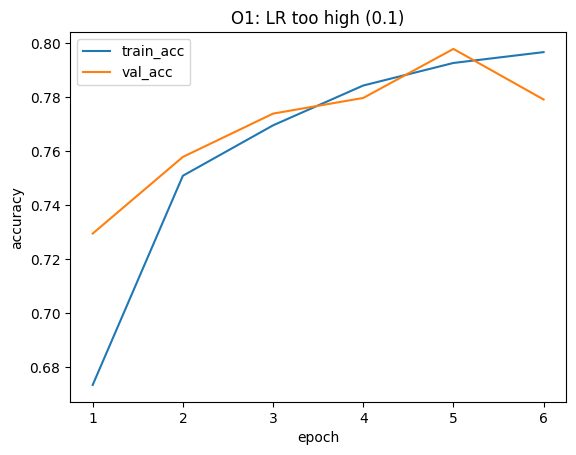

In [48]:
model_o1 = MLP(input_shape=(1, 28, 28), num_classes=NUM_CLASSES, hidden_sizes=(256, 128), dropout=0.0, use_batchnorm=True).to(device)

optimizer_o1 = optim.Adam(model_o1.parameters(), lr=0.1)
criterion = nn.CrossEntropyLoss()

history_o1 = fit(
    model_o1, train_loader, val_loader,
    optimizer_o1, criterion, device,
    epochs=6,
    early_stopping=None
)

plot_history(history_o1, title="O1: LR too high (0.1)")

In [50]:
all_results_o1 = []
metrics_o1 = get_best_metrics(history_o1)
all_results_o1.append({
    'experiment_id': 'O1',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': 'MLP(256,128), BatchNorm, lr=0.1',
    'optimizer': 'Adam',
    'lr': 0.1,
    'momentum': None,
    'weight_decay': 0.0,
    'epochs_trained': metrics_o1['epochs_trained'],
    'best_val_accuracy': metrics_o1['best_val_acc'],
    'best_val_loss': metrics_o1['best_val_loss']
})

print(f"O1 best val_acc: {metrics_o1['best_val_acc']:.4f}")

df = pd.DataFrame(all_results_o1)
df.to_csv('artifacts/runs.csv', mode='a', index=False, header=False)
print("\nРезультаты сохранены в artifacts/runs.csv")

O1 best val_acc: 0.7979

Результаты сохранены в artifacts/runs.csv


O2: LR too low (1e-5)

epoch 01/6 | train loss=3.4696, acc=0.1804 | val loss=3.1398, acc=0.3358
epoch 02/6 | train loss=2.9409, acc=0.4151 | val loss=2.7604, acc=0.4736
epoch 03/6 | train loss=2.6257, acc=0.5112 | val loss=2.4887, acc=0.5422
epoch 04/6 | train loss=2.3820, acc=0.5641 | val loss=2.2687, acc=0.5837
epoch 05/6 | train loss=2.1783, acc=0.6000 | val loss=2.0825, acc=0.6159
epoch 06/6 | train loss=2.0028, acc=0.6253 | val loss=1.9112, acc=0.6380


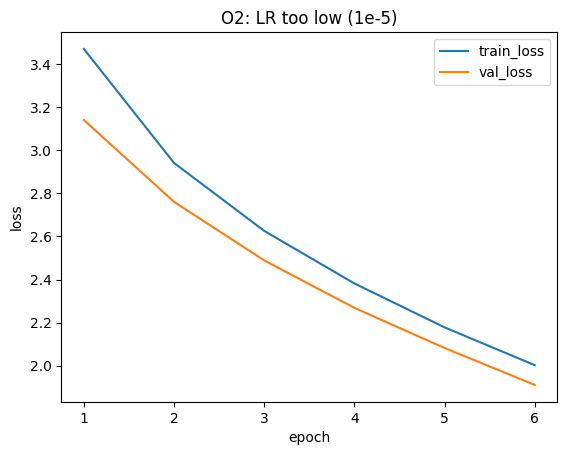

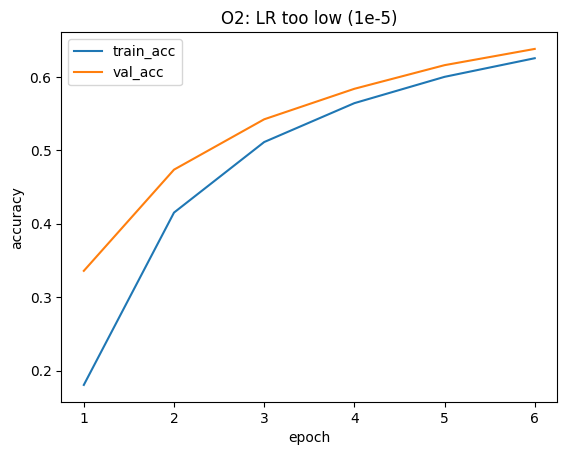

In [51]:
model_o2 = MLP(input_shape=(1, 28, 28), num_classes=NUM_CLASSES, hidden_sizes=(256, 128), dropout=0.0, use_batchnorm=True).to(device)

optimizer_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

history_o2 = fit(
    model_o2, train_loader, val_loader,
    optimizer_o2, criterion, device,
    epochs=6,
    early_stopping=None
)

plot_history(history_o2, title="O2: LR too low (1e-5)")

In [52]:
all_results_o2 = []
metrics_o2 = get_best_metrics(history_o2)
all_results_o2.append({
    'experiment_id': 'O2',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': 'MLP(256,128), BatchNorm, lr=1e-5',
    'optimizer': 'Adam',
    'lr': 1e-5,
    'momentum': None,
    'weight_decay': 0.0,
    'epochs_trained': metrics_o2['epochs_trained'],
    'best_val_accuracy': metrics_o2['best_val_acc'],
    'best_val_loss': metrics_o2['best_val_loss']
})

print(f"O2 best val_acc: {metrics_o2['best_val_acc']:.4f}")

df = pd.DataFrame(all_results_o2)
df.to_csv('artifacts/runs.csv', mode='a', index=False, header=False)
print("\nРезультаты сохранены в artifacts/runs.csv")

O2 best val_acc: 0.6380

Результаты сохранены в artifacts/runs.csv


O3 (SGD+momentum + weight decay): SGD с momentum (например, momentum=0.9) и weight_decay > 0 (например, 1e-4)

epoch 01/15 | train loss=2.4413, acc=0.4849 | val loss=1.6468, acc=0.6357
epoch 02/15 | train loss=1.3472, acc=0.6813 | val loss=1.1120, acc=0.7228
epoch 03/15 | train loss=0.9874, acc=0.7423 | val loss=0.8806, acc=0.7603
epoch 04/15 | train loss=0.8105, acc=0.7756 | val loss=0.7598, acc=0.7850
epoch 05/15 | train loss=0.7043, acc=0.7976 | val loss=0.6854, acc=0.8014
epoch 06/15 | train loss=0.6349, acc=0.8127 | val loss=0.6359, acc=0.8102
epoch 07/15 | train loss=0.5839, acc=0.8247 | val loss=0.5996, acc=0.8179
epoch 08/15 | train loss=0.5454, acc=0.8328 | val loss=0.5703, acc=0.8240
epoch 09/15 | train loss=0.5140, acc=0.8407 | val loss=0.5542, acc=0.8279
epoch 10/15 | train loss=0.4879, acc=0.8473 | val loss=0.5360, acc=0.8312
epoch 11/15 | train loss=0.4660, acc=0.8521 | val loss=0.5244, acc=0.8357
epoch 12/15 | train loss=0.4475, acc=0.8566 | val loss=0.5172, acc=0.8344
epoch 13/15 | train loss=0.4286, acc=0.8630 | val loss=0.5082, acc=0.8379
epoch 14/15 | train loss=0.4160, acc=0

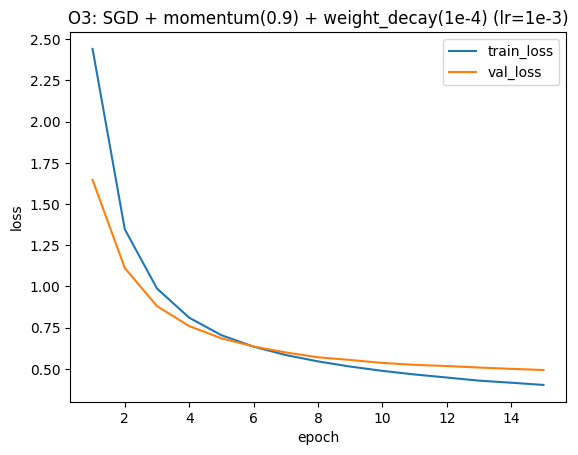

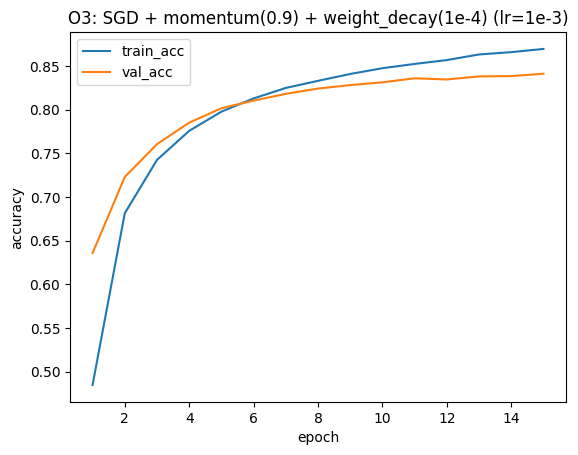

In [54]:
model_o3 = MLP(input_shape=(1, 28, 28), num_classes=NUM_CLASSES, hidden_sizes=(256, 128), dropout=0.0, use_batchnorm=True).to(device)
optimizer_o3 = optim.SGD(
    model_o3.parameters(),
    lr=1e-3,                  
    momentum=0.9,              
    weight_decay=1e-4,         
    nesterov=False 
)

criterion = nn.CrossEntropyLoss()
history_o3 = fit(
    model_o3,
    train_loader,
    val_loader,
    optimizer_o3,
    criterion,
    device,
    epochs=15,
    early_stopping=None
)

plot_history(history_o3, title="O3: SGD + momentum(0.9) + weight_decay(1e-4) (lr=1e-3)")

In [55]:
all_results_o3 = []
metrics_o3 = get_best_metrics(history_o3)
all_results_o3.append({
    'experiment_id': 'O3',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': 'MLP(256,128), BatchNorm',
    'optimizer': 'SGD',
    'lr': 1e-3,
    'momentum': 0.9,
    'weight_decay': 1e-4,
    'epochs_trained': metrics_o3['epochs_trained'],
    'best_val_accuracy': metrics_o3['best_val_acc'],
    'best_val_loss': metrics_o3['best_val_loss']
})

print(f"O3 best val_acc: {metrics_o3['best_val_acc']:.4f}")

df = pd.DataFrame(all_results_o3)
df.to_csv('artifacts/runs.csv', mode='a', index=False, header=False)
print("\nРезультаты сохранены в artifacts/runs.csv")

O3 best val_acc: 0.8410

Результаты сохранены в artifacts/runs.csv


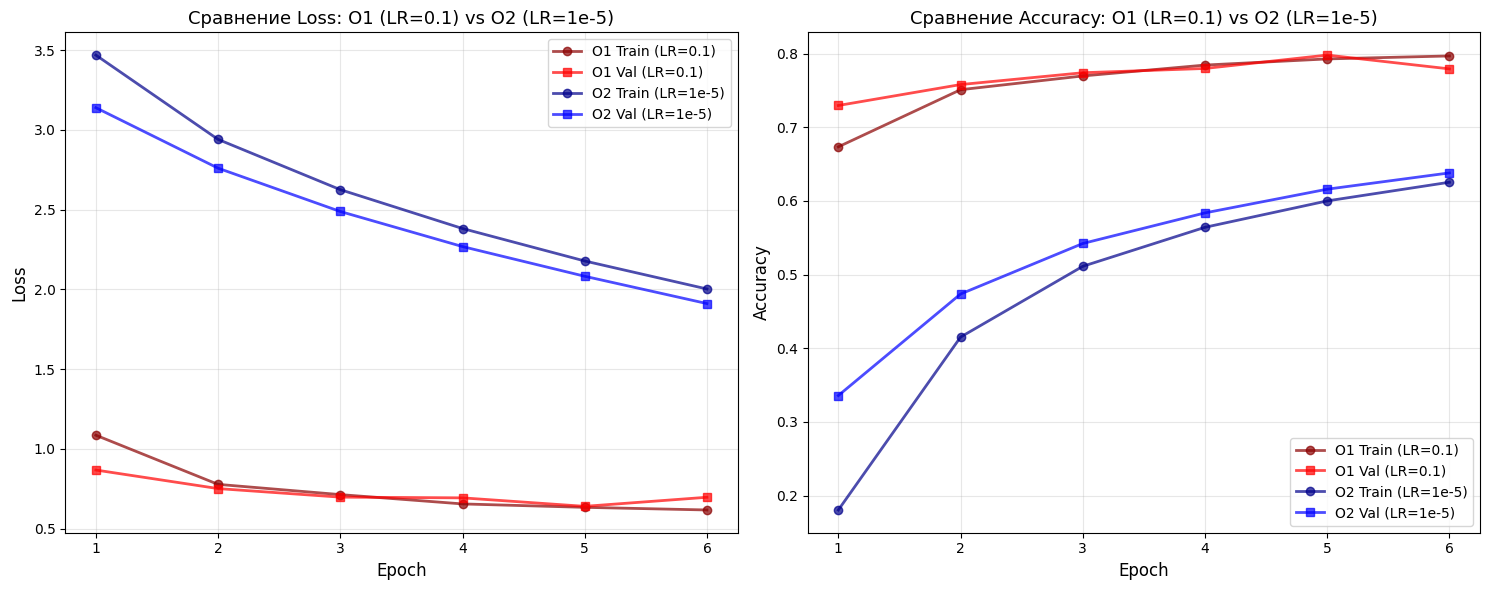

Сравнительный график сохранен: artifacts/figures/curves_lr_extremes.png


In [58]:
def plot_lr_extremes_comparison(history_o1: Dict, history_o2: Dict, save_path: str = 'artifacts/figures/curves_lr_extremes.png'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    epochs_o1 = range(1, len(history_o1["train_loss"]) + 1)
    epochs_o2 = range(1, len(history_o2["train_loss"]) + 1)
    
    # График 1: Loss
    ax1.plot(epochs_o1, history_o1["train_loss"], 'o-', color='darkred', alpha=0.7, label='O1 Train (LR=0.1)', linewidth=2, markersize=6)
    ax1.plot(epochs_o1, history_o1["val_loss"], 's-', color='red', alpha=0.7, label='O1 Val (LR=0.1)', linewidth=2, markersize=6)
    
    ax1.plot(epochs_o2, history_o2["train_loss"], 'o-', color='darkblue', alpha=0.7, label='O2 Train (LR=1e-5)', linewidth=2, markersize=6)
    ax1.plot(epochs_o2, history_o2["val_loss"], 's-', color='blue', alpha=0.7, label='O2 Val (LR=1e-5)', linewidth=2, markersize=6)
    
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Сравнение Loss: O1 (LR=0.1) vs O2 (LR=1e-5)', fontsize=13)
    ax1.legend(loc='upper right', fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    #График 2: Accuracy
    ax2.plot(epochs_o1, history_o1["train_acc"], 'o-', color='darkred', alpha=0.7, label='O1 Train (LR=0.1)', linewidth=2, markersize=6)
    ax2.plot(epochs_o1, history_o1["val_acc"], 's-', color='red', alpha=0.7, label='O1 Val (LR=0.1)', linewidth=2, markersize=6)
    
    ax2.plot(epochs_o2, history_o2["train_acc"], 'o-', color='darkblue', alpha=0.7, label='O2 Train (LR=1e-5)', linewidth=2, markersize=6)
    ax2.plot(epochs_o2, history_o2["val_acc"], 's-', color='blue', alpha=0.7, label='O2 Val (LR=1e-5)', linewidth=2, markersize=6)
    
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_title('Сравнение Accuracy: O1 (LR=0.1) vs O2 (LR=1e-5)', fontsize=13)
    ax2.legend(loc='lower right', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()    
    print(f"Сравнительный график сохранен: {save_path}")

plot_lr_extremes_comparison(history_o1, history_o2, 'artifacts/figures/curves_lr_extremes.png')